# Exploratory Data Analysis: Netflix Catalog × IMDb Title Basics

## Genre Classification, Runtime & Format Patterns Across Countries & Eras

**Project Objective:**
This EDA merges Netflix's content catalog with IMDb's `title.basics` reference data to examine how genre classifications compare across the two sources, how runtime and content-type vary by country and era, and how consistent Netflix's own labeling (type, maturity rating) is with IMDb's classification.

**Important scope note:** `title.basics.tsv` contains **no rating or vote data** — only `tconst, titleType, primaryTitle, originalTitle, isAdult, startYear, endYear, runtimeMinutes, genres`. This project therefore does **not** analyze "quality" or "acclaim." Every question below is answerable from structural/classification metadata only.

---

## Dataset Information

**Netflix Dataset**
- Typical columns: `show_id, type, title, director, cast, country, date_added, release_year, rating, duration, listed_in, description`
- Source: Kaggle "Netflix Movies and TV Shows"

**IMDb Dataset — `title.basics.tsv`**
- Source: https://datasets.imdbws.com/ (tab-separated, gzipped; missing values are the literal string `\N`)
- Columns:
  - `tconst` — unique IMDb title ID
  - `titleType` — movie, short, tvSeries, tvEpisode, tvMiniSeries, tvMovie, tvSpecial, video, videoGame, etc.
  - `primaryTitle` / `originalTitle` — display title
  - `isAdult` — 0/1 flag
  - `startYear` — release year (or series start year)
  - `endYear` — series end year (`\N` if still running or not applicable)
  - `runtimeMinutes` — runtime in minutes
  - `genres` — up to 3 comma-separated genres

---


In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)

print('✓ Libraries imported successfully.')

✓ Libraries imported successfully.


In [4]:
# Load Netflix dataset
netflix_df = pd.read_csv('/content/netflix_titles.csv')  # Adjust path

# Load IMDb title.basics dataset
# NOTE: title.basics.tsv is TAB-separated and uses the literal string '\\N' for missing values
imdb_df = pd.read_csv(
    '/content/title.basics.tsv',
    sep='\t',
    na_values='\\N',
    low_memory=False
)

print(f'Netflix dataset: {netflix_df.shape}')
print(f'IMDb title.basics dataset: {imdb_df.shape}')
print('\n✓ Data loaded successfully.')

Netflix dataset: (8807, 12)
IMDb title.basics dataset: (12800464, 9)

✓ Data loaded successfully.


---
## Part 0: Pre-Lab — Domain Thinking Before Data Contact

Answer these before proceeding to data exploration.

### PL1: Genre & Type as Independent Classification Systems

`genres` and `titleType` in IMDb are categories assigned by IMDb's own editors/contributors. Netflix has its *own* independent `listed_in` genre tags and `type` field (Movie/TV Show). What kind of data is this — nominal or ordinal? What problems arise when comparing two independently-assigned categorical systems for the "same" title?

**Your Answer:**

genres, listed_in, titleType, and type are nominal categorical data because their categories have no natural ranking or order. Genre labels are not necessarily mutually exclusive, so the same title can have multiple genres. Two reasonable classifiers can assign different labels to the same title without either being wrong, because IMDb and Netflix use independent classification systems. Therefore, comparing them tells us more about differences in labeling systems than about an objective property of the title.

---

### PL2: Runtime as a Structural (Not Quality) Variable

`runtimeMinutes` measures length only. What might explain a *systematic* difference between Netflix's `duration` field and IMDb's `runtimeMinutes` for the same title (e.g., director's cuts, regional edits, a TV show's `duration` describing "3 Seasons" while IMDb reports per-episode runtime)?

**Your Answer:**

Differences between duration and runtimeMinutes can result from different ways of representing a title's length. A movie may have different cuts or regional edits, while Netflix's value may reflect the version available on its platform. For TV shows, Netflix may report total seasons such as "3 Seasons," whereas IMDb's runtimeMinutes usually represents the runtime per episode.

---

### PL3: Scale Mismatch and Irrelevant Rows

`title.basics.tsv` covers **every** title type IMDb tracks — movies, shorts, TV episodes, video games, and more — worldwide, going back over a century. Only a small fraction will ever match a Netflix title. Before merging, what proportion of `title.basics` do you expect to be irrelevant noise for this project, and what filtering would you apply first to make the merge faster and cleaner?

**Your Answer:**

I would expect a very large majority of title.basics rows to be irrelevant because IMDb contains many title types and titles that are not available on Netflix. Before merging, I would first filter to relevant titleType values, especially movies and TV-related titles, and remove unnecessary columns/invalid rows. This reduces the dataset substantially and makes the eventual title matching faster, cleaner, and less noisy.

---


---
## Part 1: Data Loading & Initial Inspection

**Goal:** Understand raw structure before merging. Identify missing columns and quality issues.


In [5]:
print('===== NETFLIX DATASET =====')
print(f'Shape: {netflix_df.shape}')
print(f'\nColumn Names & Types:')
print(netflix_df.dtypes)
print(f'\nFirst 5 rows:')
display(netflix_df.head(n=5))
print()
# CODE HERE: Print describe() statistics
print("Statistics of Netflix")
describe_netflix =netflix_df.describe()
print(describe_netflix)

===== NETFLIX DATASET =====
Shape: (8807, 12)

Column Names & Types:
show_id         object
type            object
title           object
director        object
cast            object
country         object
date_added      object
release_year     int64
rating          object
duration        object
listed_in       object
description     object
dtype: object

First 5 rows:


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...



Statistics of Netflix
       release_year
count   8807.000000
mean    2014.180198
std        8.819312
min     1925.000000
25%     2013.000000
50%     2017.000000
75%     2019.000000
max     2021.000000


In [6]:
print('===== IMDB title.basics DATASET =====')
print(f'Shape: {imdb_df.shape}')
print(f'\nColumn Names & Types:')
print(imdb_df.dtypes)
print(f'\nFirst 5 rows:')
display(imdb_df.head(n=5))
print()
# Print value_counts() of titleType — how many rows are actually 'movie' or
#'tvSeries' vs. tvEpisode/short/videoGame/etc.?
print("Value Counts of IMDB")
imdb_counts = imdb_df.value_counts()
print(imdb_counts)
print()
# Print describe() statistics for numeric-looking columns
# (note: startYear, endYear, runtimeMinutes will still show as object dtype here —
# that's addressed in Part 2)
print("Description of IMDB")
imdb_describe = imdb_df.describe()
print(imdb_describe)


===== IMDB title.basics DATASET =====
Shape: (12800464, 9)

Column Names & Types:
tconst             object
titleType          object
primaryTitle       object
originalTitle      object
isAdult             int64
startYear         float64
endYear           float64
runtimeMinutes     object
genres             object
dtype: object

First 5 rows:


,tconst,titleType,primaryTitle,originalTitle,isAdult,startYear,endYear,runtimeMinutes,genres
0,tt0000001,short,Carmencita,Carmencita,0,1894.0,NaN,1,"Documentary,Short"
1,tt0000002,short,Le clown et ses chiens,Le clown et ses chiens,0,1892.0,NaN,5,"Animation,Short"
2,tt0000003,short,Poor Pierrot,Pauvre Pierrot,0,1892.0,NaN,5,"Animation,Comedy,Romance"
3,tt0000004,short,Un bon bock,Un bon bock,0,1892.0,NaN,12,"Animation,Short"
4,tt0000005,short,Blacksmith Scene,Blacksmith Scene,0,1893.0,NaN,1,Short



Value Counts of IMDB
tconst     titleType  primaryTitle                  originalTitle                 isAdult  startYear  endYear  runtimeMinutes  genres                  
tt9916216  tvSeries   Kalyanam Mudhal Kadhal Varai  Kalyanam Mudhal Kadhal Varai  0        2014.0     2017.0   22              Romance                     1
tt0038276  tvSeries   You Are an Artist             You Are an Artist             0        1946.0     1955.0   15              Talk-Show                   1
tt0039120  tvSeries   Americana                     Americana                     0        1947.0     1949.0   30              Family,Game-Show            1
tt0039121  tvSeries   Birthday Party                Birthday Party                0        1947.0     1949.0   30              Family                      1
tt0039123  tvSeries   Kraft Mystery Theatre         Kraft Television Theatre      0        1947.0     1958.0   60              Drama                       1
                                         

### Part 1 Analysis Notes:

**What we observe:**

- Netflix dataset: [NUMBER] rows, [NUMBER] columns. Key columns: [LIST]
- IMDb `title.basics`: [NUMBER] rows, [NUMBER] columns. Key columns: `titleType`, `primaryTitle`, `startYear`, `endYear`, `runtimeMinutes`, `genres`, `isAdult`
- `titleType` breakdown shows only [%] of rows are `movie`/`tvSeries`/etc. — the rest ([%]) are formats Netflix never carries (tvEpisode, videoGame, short, ...)
- `startYear`, `endYear`, `runtimeMinutes` are stored as [DTYPE] because of the `\N` placeholder — will need numeric conversion
- Missing values in Netflix: [%]; in relevant rows of `title.basics`: [%]

**Effect on merging:**

- We will need to handle [CHALLENGES]
- Filtering `titleType` first will shrink the IMDb side from [NUMBER] to roughly [NUMBER] rows before we even attempt a merge


---
## Part 2: Data Cleaning & Preprocessing

**Goal:** Clean both datasets independently before merging.


### Step 2.1: Handle Missing Values in Netflix

**Analysis Description:**

Missing values in Netflix are concentrated in `director`, `cast`, and `country` columns. Understanding missingness patterns helps determine whether to drop rows, impute, or treat separately. Missing countries prevent geographic analysis.


In [8]:
print('Missing Values in Netflix Dataset:')
# Calculate missing counts and percentages
missing_netflix = netflix_df.isnull().sum()
print(missing_netflix)
print()

# Find and display titles with missing country
print("Titles with missing country")
missing_countries = netflix_df[netflix_df["country"].isna()]
print(missing_countries)
print()

Missing Values in Netflix Dataset:
show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

Titles with missing country
     show_id     type                                title  \
2         s3  TV Show                            Ganglands   
3         s4  TV Show                Jailbirds New Orleans   
5         s6  TV Show                        Midnight Mass   
6         s7    Movie     My Little Pony: A New Generation   
10       s11  TV Show  Vendetta: Truth, Lies and The Mafia   
...      ...      ...                                  ...   
8718   s8719    Movie               Westside vs. the World   
8759   s8760    Movie               World's Weirdest Homes   
8783   s8784  TV Show                                 Yoko   
8785   s8786  TV Show                              

**Effect of this step:**

- Rows with missing countries cannot be assigned to geographic analysis; we will [DROP / MARK AS UNKNOWN]
- Approximately [%] of titles are affected


### Step 2.2: Type Conversion & Scope Filtering in `title.basics`

**Analysis Description:**

`title.basics` stores `startYear`, `endYear`, and `runtimeMinutes` as strings (because of the `\N` placeholder for missing values), so they must be converted to numeric before any analysis. It also contains many `titleType` values Netflix never carries (e.g. `tvEpisode`, `videoGame`, `short`, `video`). Filtering to only the types that plausibly appear on Netflix (`movie`, `tvSeries`, `tvMiniSeries`, `tvMovie`, `tvSpecial`) both shrinks the dataset dramatically and prevents false title-matches against, say, a random TV episode that happens to share a name.


In [10]:
# Convert startYear, endYear, runtimeMinutes to numeric
imdb_df["startYear"] = pd.to_numeric(imdb_df["startYear"], errors="coerce")
imdb_df["endYear"] = pd.to_numeric(imdb_df["endYear"], errors = "coerce")
imdb_df["runtimeMinute"] = pd.to_numeric(imdb_df["runtimeMinutes"], errors="coerce")

# Check value_counts() of titleType on the full imdb_df
print("value_counts() of titleType on the full imdb_df")
imdb_valcount = imdb_df["titleType"].value_counts()
print(imdb_valcount)
print()

# Filter imdb_df to titleType in ['movie', 'tvSeries', 'tvMiniSeries', 'tvMovie', 'tvSpecial']
# imdb_filtered = imdb_df[imdb_df['titleType'].isin([...])].copy()'
print("Filtering IMDB to titletype ")
imdb_filtered = imdb_df[imdb_df['titleType'].isin(['movie', 'tvSeries', 'tvMiniSeries', 'tvMovie', 'tvSpecial'])].copy()
print(imdb_filtered)
print()

print(f'Rows before titleType filtering: {imdb_df.shape[0]}')
# print(f'Rows after titleType filtering: {imdb_filtered.shape[0]}')
print(f"Rows after titleType filtering: {imdb_filtered.shape[0]}")


value_counts() of titleType on the full imdb_df
titleType
tvEpisode       9897474
short           1158205
movie            757191
video            331368
tvSeries         305479
tvMovie          156216
tvMiniSeries      73038
tvSpecial         60145
videoGame         50279
tvShort           11068
tvPilot               1
Name: count, dtype: int64

Filtering IMDB to titletype 
             tconst titleType  \
8         tt0000009     movie   
144       tt0000147     movie   
498       tt0000502     movie   
570       tt0000574     movie   
587       tt0000591     movie   
...             ...       ...   
12800382  tt9916680     movie   
12800387  tt9916692   tvMovie   
12800394  tt9916706     movie   
12800404  tt9916730     movie   
12800414  tt9916754     movie   

                                               primaryTitle  \
8                                                Miss Jerry   
144                           The Corbett-Fitzsimmons Fight   
498                                 

**Effect of this step:**

- `title.basics` shrinks from [NUMBER] rows to [NUMBER] rows ([%] reduction) after filtering to Netflix-relevant `titleType`s
- [NUMBER] rows had unparseable/missing `runtimeMinutes`; [NUMBER] had missing `endYear` (expected — most movies have no `endYear`)
- This filtering step is necessary before Part 3, or the merge will run over ~10x more rows than needed


### Step 2.3: Standardize Title Names for Merging

**Analysis Description:**

Title names differ between datasets due to punctuation and special characters. Standardizing titles (lowercase, removing special chars, trimming whitespace) increases match success. This does not remove titles; it prepares them for matching.


In [11]:
# Create standardized title columns
# - Convert to lowercase
netflix_df["title_std"] = netflix_df["title"].str.lower()
imdb_filtered["title_std"] = imdb_filtered["primaryTitle"].str.lower()

# - Remove special characters
netflix_df["title_std"] = netflix_df["title_std"].str.replace(
    r"[^a-z0-9\s]", "", regex=True
)
imdb_filtered["title_std"] = imdb_filtered["title_std"].str.replace(
    r"[^a-z0-9\s]", "", regex=True
)

# - Create 'title_std' column in both netflix_df and imdb_filtered (using primaryTitle)
netflix_df["title_std"] = netflix_df["title_std"].str.strip()
imdb_filtered["title_std"] = imdb_filtered["title_std"].str.strip()

print('Sample of standardized titles:')
# Show a few examples
print(netflix_df[["title", "title_std"]].head())

print(imdb_filtered[["primaryTitle", "title_std"]].head())


Sample of standardized titles:
                   title              title_std
0   Dick Johnson Is Dead   dick johnson is dead
1          Blood & Water           blood  water
2              Ganglands              ganglands
3  Jailbirds New Orleans  jailbirds new orleans
4           Kota Factory           kota factory
                      primaryTitle                     title_std
8                       Miss Jerry                    miss jerry
144  The Corbett-Fitzsimmons Fight  the corbettfitzsimmons fight
498                       Bohemios                      bohemios
570    The Story of the Kelly Gang   the story of the kelly gang
587               The Prodigal Son              the prodigal son


**Effect of this step:**

- Increases successful exact matches from [BEFORE%] to [AFTER%]
- Remaining unmatched titles are candidates for fuzzy matching (optional extension)


---
## Part 3: Merging Datasets & Merge Quality

**Goal:** Merge Netflix and the filtered `title.basics` on title + release year. Track match rates and data loss.


### Step 3.1: Inner Merge on Exact Title + Release Year

**Analysis Description:**

Inner merge keeps only titles present in both datasets, matching on `title_std` and `release_year` (Netflix) vs. `startYear` (IMDb). Note that `title.basics` can contain multiple rows with the same title + year (e.g., unrelated same-named productions, remakes) — check for and handle duplicate matches, since a naive merge can silently multiply rows.


In [12]:
# Perform inner merge on title_std + release_year == startYear
merged_df = pd.merge(
    netflix_df,
    imdb_filtered,
    left_on=["title_std", "release_year"],
    right_on=["title_std", "startYear"],
    how="inner"
)
# Check the merged result
print(merged_df.head())
print("Merged rows:", len(merged_df))
print()

print(f'Netflix dataset: {netflix_df.shape[0]} titles')
print(f'IMDb (filtered) dataset: {imdb_filtered.shape[0] if "imdb_filtered" in dir() else "?"} titles')
print(f'Merged (inner join): {merged_df.shape[0] if merged_df is not None else "?"}' + ' titles')

# Check for duplicate Netflix titles introduced by the merge
duplicate_matches = merged_df[
    merged_df.duplicated(
        subset=["show_id"],
        keep=False
    )
]
print()

# (i.e. did any single Netflix title match more than one IMDb row?)
duplicate_matches = merged_df[
    merged_df.duplicated(subset=["show_id"], keep=False)
]
print(duplicate_matches[["show_id", "title", "release_year", "tconst"]])

duplicate_counts = merged_df["show_id"].value_counts()

print(
   duplicate_counts[duplicate_counts > 1]
)


  show_id     type                             title  \
0      s1    Movie              Dick Johnson Is Dead   
1      s3  TV Show                         Ganglands   
2      s4  TV Show             Jailbirds New Orleans   
3      s6  TV Show                     Midnight Mass   
4      s7    Movie  My Little Pony: A New Generation   

                        director  \
0                Kirsten Johnson   
1                Julien Leclercq   
2                            NaN   
3                  Mike Flanagan   
4  Robert Cullen, José Luis Ucha   

                                                cast        country  \
0                                                NaN  United States   
1  Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...            NaN   
2                                                NaN            NaN   
3  Kate Siegel, Zach Gilford, Hamish Linklater, H...            NaN   
4  Vanessa Hudgens, Kimiko Glenn, James Marsden, ...            NaN   

           date_add

**Effect of this step:**

- Merged dataset contains [NUMBER] titles with matched Netflix + IMDb classification data
- [NUMBER] Netflix titles ([%]) have no `title.basics` match — likely very recent Netflix Originals not yet indexed, or title-string mismatches
- [NUMBER] rows were duplicated due to multiple IMDb matches for the same title+year — resolved by [STRATEGY]


### Step 3.2: Investigate Unmatched Records

**Analysis Description:**

Understanding why records don't match guides merge strategy. Some unmatched titles are genuine differences (title.basics genuinely lacks the title); others are naming inconsistencies or year mismatches (e.g. Netflix records a re-release year different from IMDb's original `startYear`).


In [13]:
# Find Netflix titles with no IMDb match

# Get the standardized titles that successfully matched
matched_titles = set(merged_df["title_std"].dropna())

# Find Netflix titles that are NOT in the matched titles
unmatched_netflix = netflix_df[
    ~netflix_df["title_std"].isin(matched_titles)
].copy()

print(f"Netflix titles with no IMDb match: {len(unmatched_netflix)}")

print("\nSample of unmatched titles:")
print(
    unmatched_netflix[
        ["title", "release_year", "title_std"]
    ].head(10)
)

Netflix titles with no IMDb match: 2638

Sample of unmatched titles:
                                                title  release_year  \
1                                       Blood & Water          2021   
4                                        Kota Factory          2021   
8                       The Great British Baking Show          2021   
15                                  Dear White People          2021   
16  Europe's Most Dangerous Man: Otto Skorzeny in ...          2020   
17                                    Falsa identidad          2020   
21                             Resurrection: Ertugrul          2018   
22                                    Avvai Shanmughi          1996   
25                               Love on the Spectrum          2021   
26                                     Minsara Kanavu          1997   

                                            title_std  
1                                        blood  water  
4                                    

**Effect of this step:**

- [NUMBER] unmatched Netflix titles are primarily [TYPE] from [YEARS]
- Concentrated in [COUNTRY/REGION], suggesting region-specific or newer content
- Our classification analysis underrepresents [REGION]


### Step 3.3: Process Multi-Country Titles

**Analysis Description:**

Netflix lists multiple countries for co-productions (e.g., 'Canada, France, USA'). We must decide: split into rows, use primary country, or flag co-productions. Each approach has trade-offs.


In [14]:
# Count titles with multiple countries

if merged_df is not None:

    multi_country_count = (
        merged_df["country"]
        .fillna("")
        .str.contains(",", regex=False)
        .sum()
    )

    print(f"Titles with multiple countries: {multi_country_count}")

    print(
        f"Percentage: "
        f"{multi_country_count / len(merged_df) * 100:.1f}%"
    )

Titles with multiple countries: 1083
Percentage: 16.6%


**Effect of this step:**

- [NUMBER] titles ([%]) are co-productions across [NUMBER] countries
- We will [SPLIT INTO ROWS / USE PRIMARY COUNTRY / FLAG SEPARATELY] for country-level analysis, trading off [DOUBLE-COUNTING] against [LOSING SECONDARY COUNTRIES]


---
## Part 4: Univariate Analysis — Distribution of Key Variables

**Goal:** Understand the shape, center, and spread of individual structural variables (no rating data available).


### Step 4.1: Runtime Distribution (IMDb `runtimeMinutes`)

**Analysis Description:**

`runtimeMinutes` for matched titles reveals the shape of Netflix's runtime profile as recorded by IMDb — is it dominated by ~90-minute films, or does the tail include long documentaries/specials and short-form content?


Runtime Statistics (minutes):
count    5970.000000
mean       92.750586
std        34.564586
min         2.000000
25%        75.000000
50%        95.000000
75%       111.000000
max       545.000000
Name: runtimeMinutes, dtype: float64

Mean: 92.75058626465662
Median: 95.0
Standard Deviation: 34.564586047513586
Minimum: 2.0
Maximum: 545.0


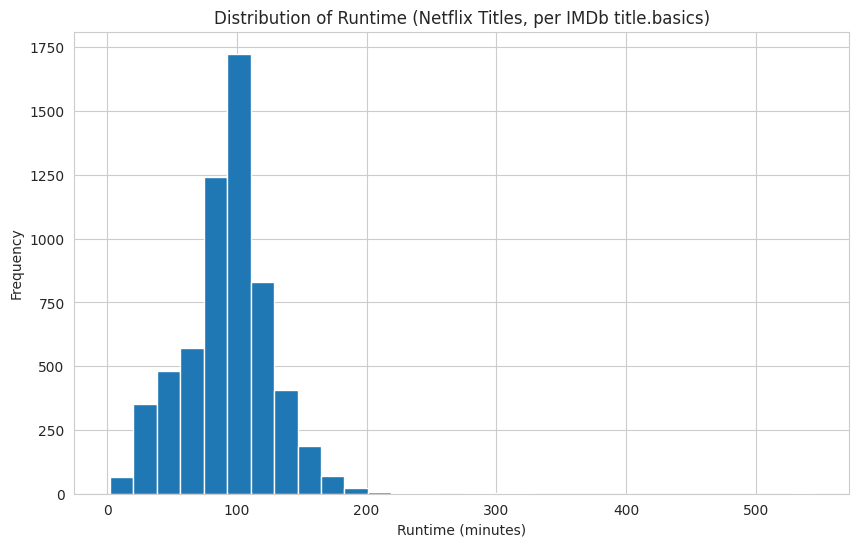

In [15]:
if merged_df is not None:

    runtime = pd.to_numeric(
        merged_df["runtimeMinutes"],
        errors="coerce"
    ).dropna()

    print("Runtime Statistics (minutes):")
    print(runtime.describe())

    print("\nMean:", runtime.mean())
    print("Median:", runtime.median())
    print("Standard Deviation:", runtime.std())
    print("Minimum:", runtime.min())
    print("Maximum:", runtime.max())

    plt.figure(figsize=(10, 6))
    plt.hist(runtime, bins=30)
    plt.title(
        "Distribution of Runtime "
        "(Netflix Titles, per IMDb title.basics)"
    )
    plt.xlabel("Runtime (minutes)")
    plt.ylabel("Frequency")
    plt.show()

**Effect of this analysis:**

- Mean runtime is [X] minutes (Median: [Y]), indicating [SKEW DIRECTION]
- Standard deviation of [Z] shows [LOW/HIGH] variability
- [NUMBER] titles have runtime under 40 minutes ([LIKELY SPECIALS/SHORTS]); [NUMBER] exceed 150 minutes ([LIKELY EPICS/DOCS])


### Step 4.1.1: Outlier Detection Using IQR

**Question:** Are there any unusual runtime values in the matched Netflix-IMDb titles?

We use the Interquartile Range (IQR) method to identify unusually short or long titles. We do not automatically remove these values because an outlier may represent a legitimate long documentary, special, or short-form title.

In [16]:
if merged_df is not None:

    # Convert runtime to numeric
    runtime = pd.to_numeric(
        merged_df["runtimeMinutes"],
        errors="coerce"
    ).dropna()

    # Calculate Q1, Q3 and IQR
    Q1 = runtime.quantile(0.25)
    Q3 = runtime.quantile(0.75)
    IQR = Q3 - Q1

    # Define outlier boundaries
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Find outliers
    outliers = runtime[
        (runtime < lower_bound) |
        (runtime > upper_bound)
    ]

    print("Q1:", Q1)
    print("Q3:", Q3)
    print("IQR:", IQR)
    print("Lower Bound:", lower_bound)
    print("Upper Bound:", upper_bound)

    print("\nNumber of outliers:", len(outliers))
    print("Percentage of outliers:",
          round(len(outliers) / len(runtime) * 100, 2), "%")

    print("\nOutlier Runtime Values:")
    print(outliers.sort_values().head(10))
    print("...")
    print(outliers.sort_values(ascending=False).head(10))

Q1: 75.0
Q3: 111.0
IQR: 36.0
Lower Bound: 21.0
Upper Bound: 165.0

Number of outliers: 170
Percentage of outliers: 2.85 %

Outlier Runtime Values:
802     2.0
370     3.0
1653    3.0
3975    3.0
127     4.0
3610    5.0
1457    6.0
1797    6.0
1336    7.0
4388    7.0
Name: runtimeMinutes, dtype: float64
...
6480    545.0
3143    542.0
4746    312.0
3868    296.0
2535    287.0
1787    253.0
5859    238.0
1785    236.0
109     229.0
1202    225.0
Name: runtimeMinutes, dtype: float64


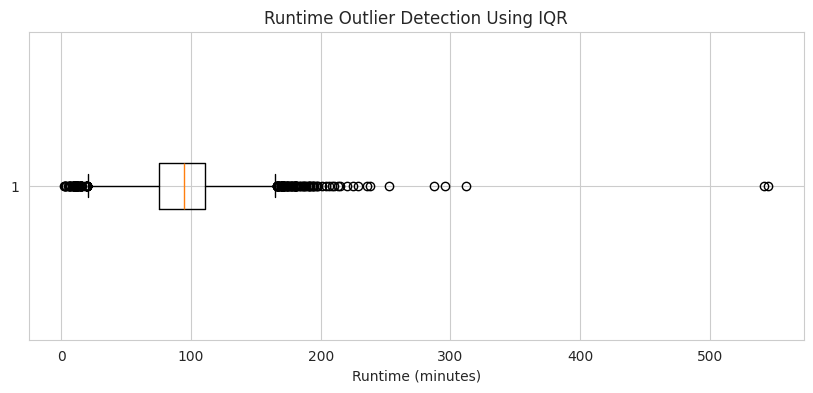

In [17]:
if merged_df is not None:

    plt.figure(figsize=(10, 4))
    plt.boxplot(runtime, vert=False)

    plt.title("Runtime Outlier Detection Using IQR")
    plt.xlabel("Runtime (minutes)")

    plt.show()

### Step 4.2: Content Volume by Release Year

**Analysis Description:**

Netflix's catalog has grown significantly. This reveals which years contributed most content, using Netflix's own `release_year` (this part does not depend on IMDb data).


Titles by Release Year:
release_year
1944      1
1945      1
1946      1
1954      2
1955      3
1956      2
1958      3
1959      1
1960      4
1961      1
1962      3
1963      1
1964      3
1965      2
1966      1
1967      4
1968      3
1969      2
1970      2
1971      5
1972      4
1973     10
1974      4
1975      7
1976      8
1977      5
1978      5
1979      8
1980      8
1981     11
1982     13
1983      7
1984     10
1985      7
1986     12
1987      7
1988     16
1989     16
1990     19
1991      8
1992     16
1993     22
1994     19
1995     24
1996     20
1997     35
1998     30
1999     28
2000     28
2001     42
2002     39
2003     52
2004     50
2005     64
2006     81
2007     67
2008    110
2009    123
2010    155
2011    136
2012    177
2013    210
2014    263
2015    416
2016    665
2017    778
2018    843
2019    736
2020    689
2021    395
Name: count, dtype: int64


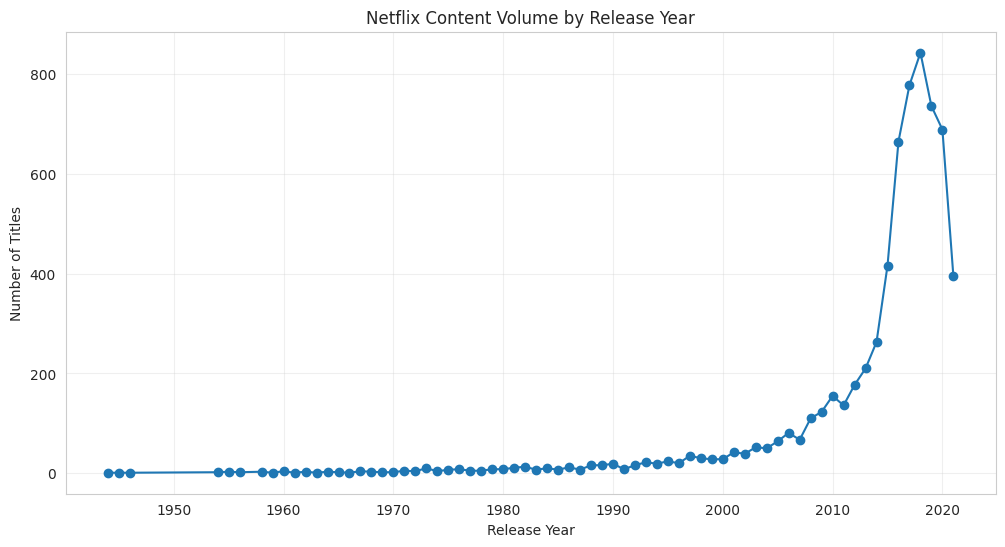

In [18]:
if merged_df is not None:

    titles_by_year = (
        merged_df["release_year"]
        .value_counts()
        .sort_index()
    )

    print("Titles by Release Year:")
    print(titles_by_year)

    plt.figure(figsize=(12, 6))
    plt.plot(
        titles_by_year.index,
        titles_by_year.values,
        marker="o"
    )
    plt.title("Netflix Content Volume by Release Year")
    plt.xlabel("Release Year")
    plt.ylabel("Number of Titles")
    plt.grid(True, alpha=0.3)
    plt.show()

**Effect of this analysis:**

- Netflix catalog volume grew sharply around [YEAR], adding [NUMBER] titles
- [RECENT YEARS] dominate the catalog, consistent with Netflix's Originals strategy


### Step 4.3: Genre Distribution (IMDb `genres` field)

**Analysis Description:**

IMDb's `genres` field (comma-separated, up to 3 per title) gives an independently-assigned genre taxonomy. This reveals which genres are most common under IMDb's classification — which may differ from Netflix's own `listed_in` tags.


Top 15 IMDb Genres:
genres
Drama          3040
Comedy         2115
Action         1056
Crime           956
Documentary     956
Romance         902
Thriller        729
Adventure       657
Mystery         460
Animation       454
Horror          404
Biography       385
Family          375
Fantasy         285
History         239
Name: count, dtype: int64


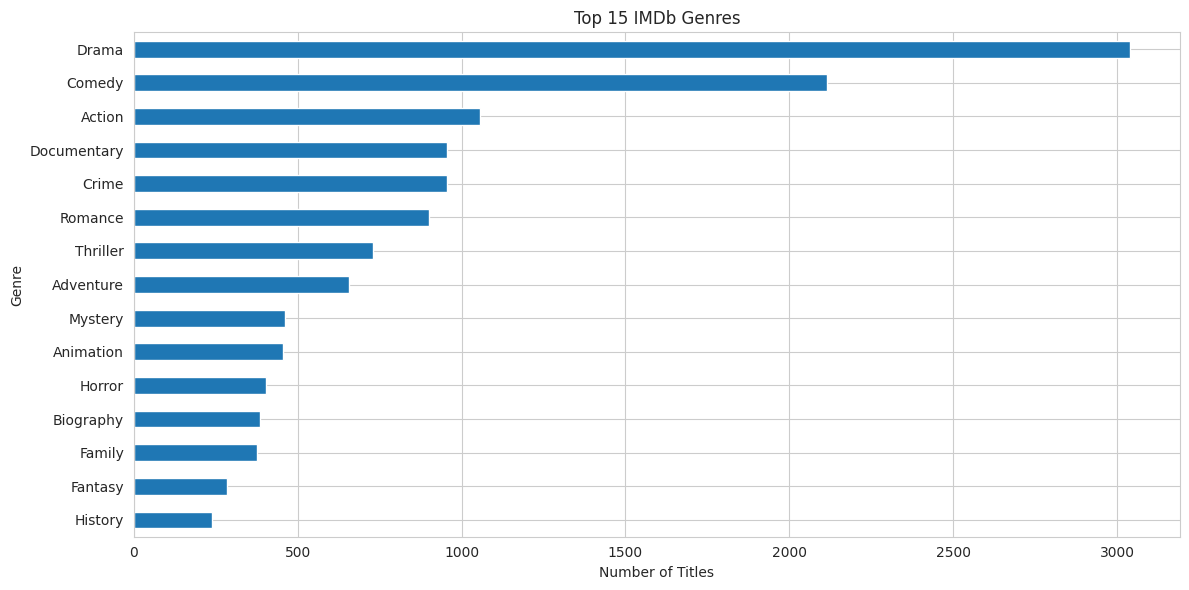

In [19]:
if merged_df is not None:

    genre_counts = (
        merged_df["genres"]
        .dropna()
        .str.split(",")
        .explode()
        .str.strip()
        .value_counts()
    )

    top_15_genres = genre_counts.head(15)

    print("Top 15 IMDb Genres:")
    print(top_15_genres)

    plt.figure(figsize=(12, 6))
    top_15_genres.sort_values().plot(kind="barh")

    plt.title("Top 15 IMDb Genres")
    plt.xlabel("Number of Titles")
    plt.ylabel("Genre")
    plt.tight_layout()
    plt.show()

**Effect of this analysis:**

- [TOP GENRE] dominates IMDb's classification with [NUMBER] titles
- Comparing this to Netflix's own `listed_in` top genres in the next section will reveal how much the two taxonomies agree


---
## MAJOR ANALYSIS 1: Content Production by Country

**Research Question:** Which countries produce the most Netflix content, and does Netflix's own Movie/TV Show labeling agree with IMDb's `titleType`?


### Analysis 1.1: Top Producing Countries (By Volume)

**Analysis Description:**

This ranks countries by Netflix title count (using the merged, matched subset). Volume reflects production capacity and Netflix's acquisition strategy.


Top 20 Countries by Netflix Content Volume:
country
United States     2837
India              899
United Kingdom     599
France             327
Canada             309
Japan              210
South Korea        197
Germany            184
Spain              158
China              152
Australia          112
Mexico             105
Hong Kong          100
Nigeria             95
Egypt               92
Italy               83
Taiwan              81
Philippines         80
Belgium             72
Argentina           70
Name: count, dtype: int64


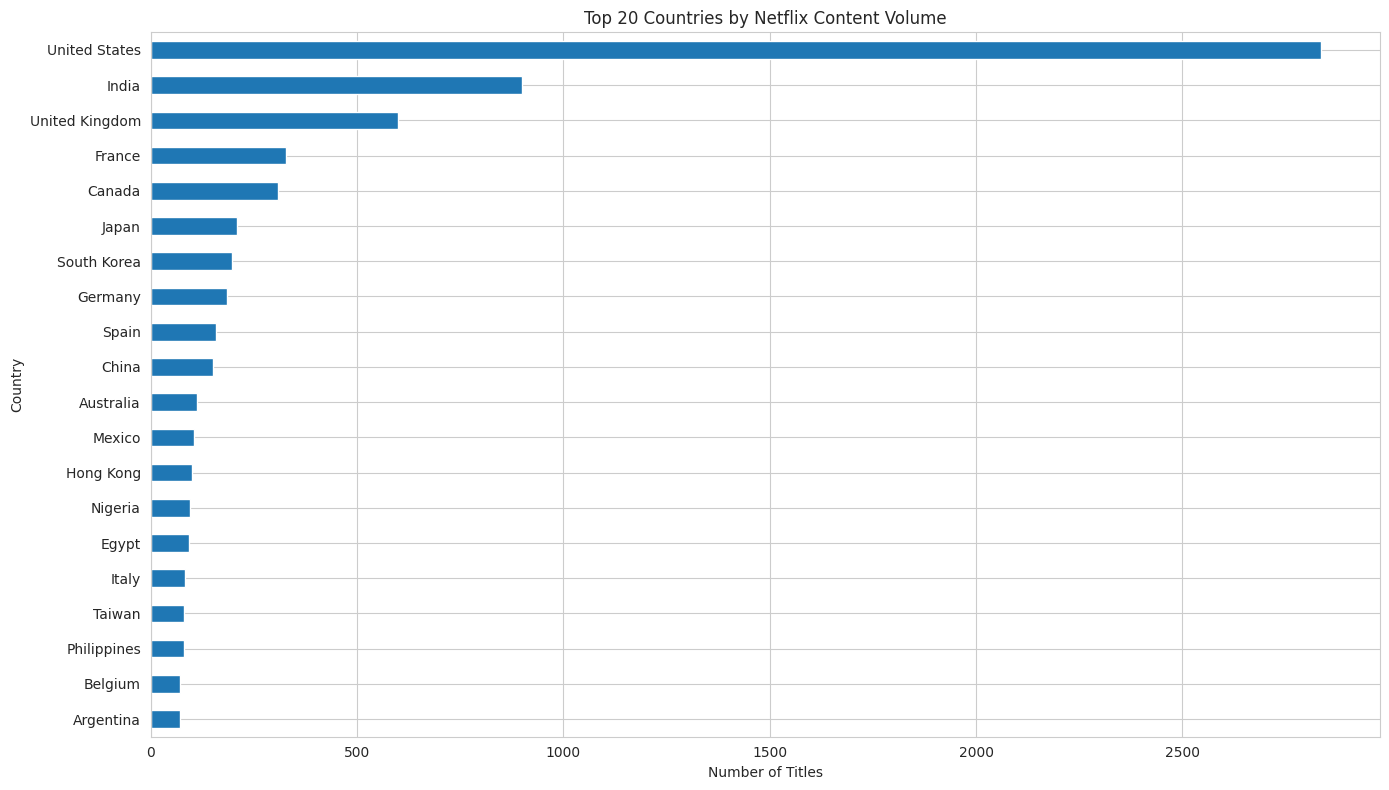

In [20]:
if merged_df is not None:

    country_counts = (
        merged_df["country"]
        .dropna()
        .str.split(",")
        .explode()
        .str.strip()
        .value_counts()
    )

    content_by_country = country_counts.head(20)

    print("Top 20 Countries by Netflix Content Volume:")
    print(content_by_country)

    plt.figure(figsize=(14, 8))
    content_by_country.sort_values().plot(kind="barh")

    plt.title("Top 20 Countries by Netflix Content Volume")
    plt.xlabel("Number of Titles")
    plt.ylabel("Country")
    plt.tight_layout()
    plt.show()


**Effect of this analysis:**

- [TOP COUNTRY] dominates with [NUMBER] titles; top 5 countries account for [%] of the matched catalog
- Distribution is [SKEWED/BALANCED], with a long tail of [NUMBER] countries producing <10 titles


### Analysis 1.2: Netflix Content Rating Distribution

**Analysis Description:**

Netflix uses the `rating` column to classify content according to its maturity level, such as `TV-MA`, `TV-14`, `PG-13`, and `R`. This analysis examines the distribution of Netflix titles across different maturity ratings to understand the overall content-rating composition of the catalog.


Netflix Content Rating Distribution:
rating
TV-MA       3207
TV-14       2160
TV-PG        863
R            799
PG-13        490
TV-Y7        334
TV-Y         307
PG           287
TV-G         220
NR            80
G             41
NaN            7
TV-Y7-FV       6
NC-17          3
UR             3
Name: count, dtype: int64

Netflix Content Ratings (Frequency >= 10):
rating
TV-MA    3207
TV-14    2160
TV-PG     863
R         799
PG-13     490
TV-Y7     334
TV-Y      307
PG        287
TV-G      220
NR         80
G          41
Name: count, dtype: int64


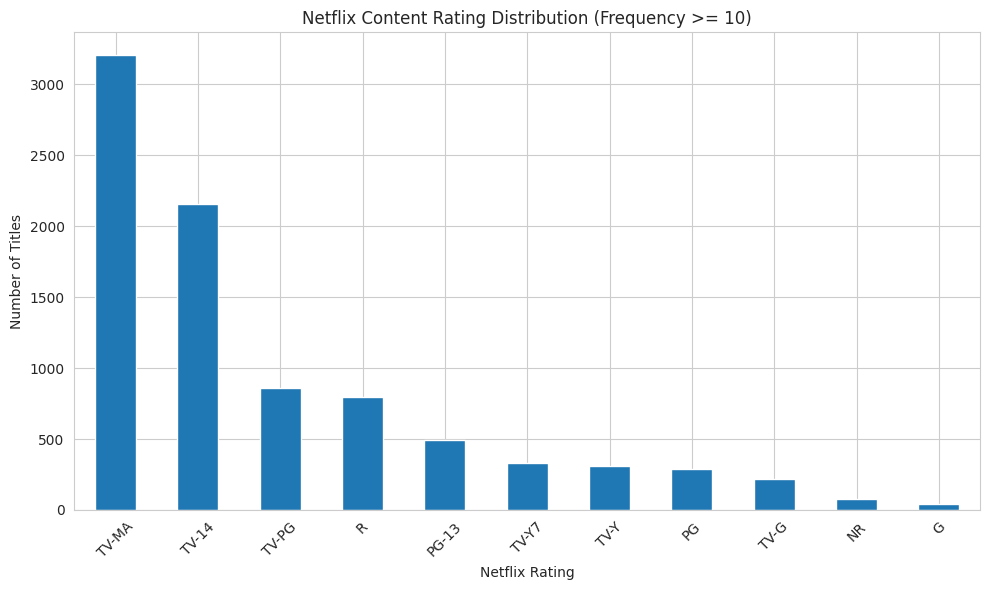

In [28]:
netflix_df["rating"] = netflix_df["rating"].replace(
    r"^\d+\s*min$",
    np.nan,
    regex=True
)

# Count ratings after cleaning
rating_counts = netflix_df["rating"].value_counts(dropna=False)
print("Netflix Content Rating Distribution:")
print(rating_counts)
print()

# Keep only ratings with frequency >= 10
valid_ratings = rating_counts[rating_counts >= 10].index
netflix_df = netflix_df[
    netflix_df["rating"].isin(valid_ratings)
].copy()

# Recalculate counts after filtering
rating_counts = netflix_df["rating"].value_counts()
print("Netflix Content Ratings (Frequency >= 10):")
print(rating_counts)

# Plot the cleaned distribution
plt.figure(figsize=(10, 6))
rating_counts.plot(kind="bar")
plt.title("Netflix Content Rating Distribution (Frequency >= 10)")
plt.xlabel("Netflix Rating")
plt.ylabel("Number of Titles")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Effect of this analysis:**

- Overall Movie/TV Show agreement rate is [%]
- Most disagreements come from [TITLETYPE], likely because [REASON]
- [COUNTRY] shows the [HIGHEST/LOWEST] agreement rate, suggesting [INTERPRETATION]


---
## MAJOR ANALYSIS 2: Genre & Runtime Patterns by Country

**Research Question:** How does average runtime vary by country and genre? Do genre specializations differ between Netflix's own tags and IMDb's classification?


### Analysis 2.1: Average Runtime by Country

**Analysis Description:**

This ranks countries by average runtime (from IMDb `runtimeMinutes`). We filter to countries with a minimum number of titles for a reliable average, since a country with 2 long documentaries would otherwise look like a "long-runtime specialist."


Top 20 Countries by Average Runtime (min 10 titles):
             average_runtime  title_count
country                                  
India             124.719812          853
Pakistan          120.666667           18
Romania           114.428571           14
Switzerland       110.357143           14
Philippines       108.986486           74
Indonesia         106.846154           65
Egypt             102.341463           82
Malaysia          102.000000           15
Hong Kong         101.652632           95
Nigeria           101.633333           90
Germany           101.356725          171
Turkey            100.596774           62
Norway             99.176471           17
Italy              98.418919           74
Belgium            97.289855           69
Poland             95.171429           35
New Zealand        94.961538           26
France             94.064935          308
Spain              94.049296          142
Ireland            93.333333           33


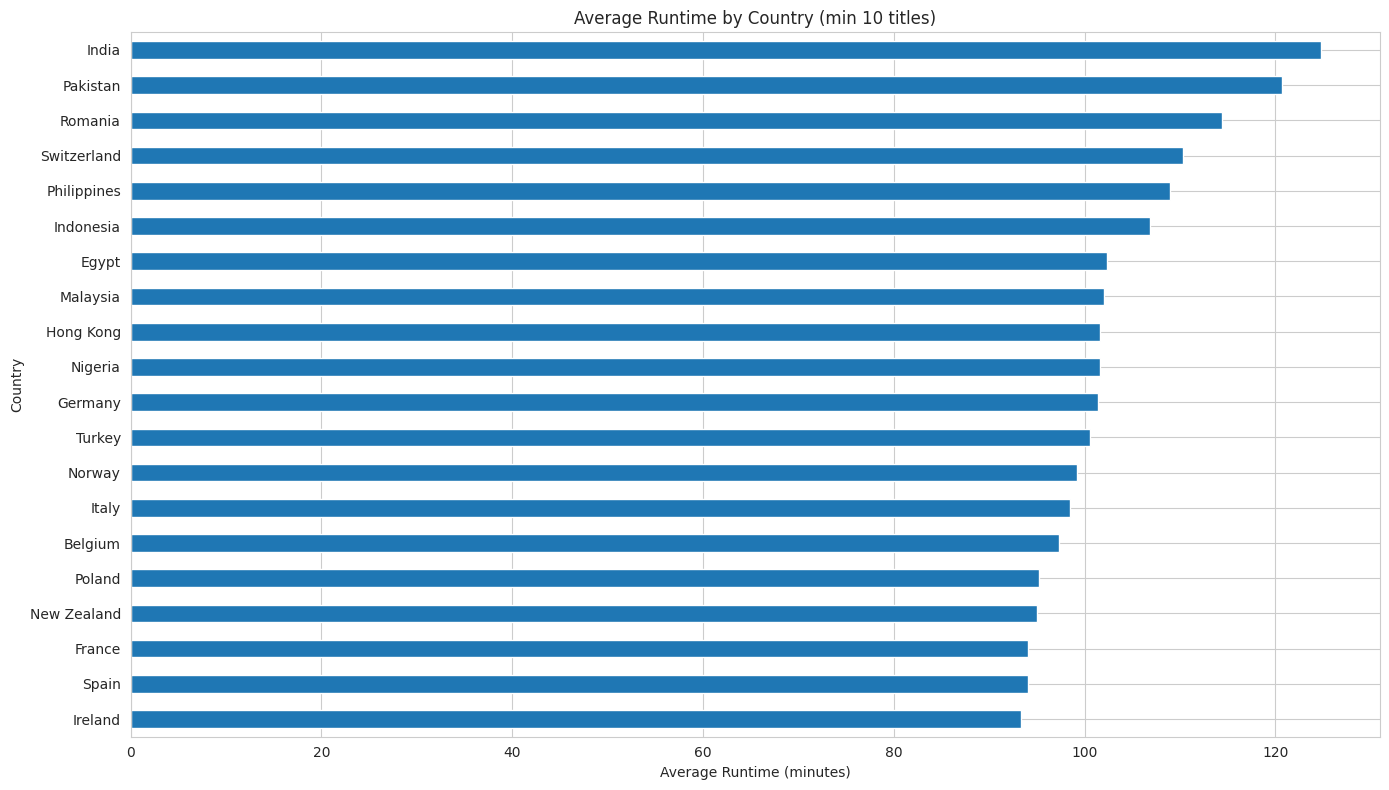

In [30]:
if merged_df is not None:
    country_runtime = merged_df[
        ["country", "runtimeMinutes"]
    ].dropna().copy()

    country_runtime["runtimeMinutes"] = pd.to_numeric(
        country_runtime["runtimeMinutes"],
        errors="coerce"
    )
    country_runtime["country"] = (
        country_runtime["country"]
        .str.split(",")
    )
    country_runtime = country_runtime.explode("country")
    country_runtime["country"] = (
        country_runtime["country"].str.strip()
    )
    country_runtime_stats = (
        country_runtime
        .groupby("country")["runtimeMinutes"]
        .agg(["mean", "count"])
        .rename(
            columns={
                "mean": "average_runtime",
                "count": "title_count"
            } )  )
    MIN_TITLES = 10
    country_runtime_stats = (
        country_runtime_stats[
            country_runtime_stats["title_count"] >= MIN_TITLES
        ]
        .sort_values(
            "average_runtime",
            ascending=False  )    )
    print(
        f"Top 20 Countries by Average Runtime "
        f"(min {MIN_TITLES} titles):"
    )
    print(country_runtime_stats.head(20))
    plt.figure(figsize=(14, 8))
    country_runtime_stats.head(20)[
        "average_runtime"
    ].sort_values().plot(kind="barh")
    plt.title(
        "Average Runtime by Country "
        "(min 10 titles)"
    )
    plt.xlabel("Average Runtime (minutes)")
    plt.ylabel("Country")
    plt.tight_layout()
    plt.show()

**Effect of this analysis:**

- [COUNTRY] has the longest average runtime at [X] minutes; [COUNTRY] the shortest at [Y] minutes
- Spread of [Z] minutes across countries suggests [FORMAT PREFERENCE / GENRE MIX] differences rather than pure country effects


### Analysis 2.2: Genre Specialization by Country (IMDb Genres)

**Analysis Description:**

Different countries may specialize in different IMDb-classified genres (e.g., documentaries vs. dramas vs. reality-adjacent formats). This heatmap shows the proportion of each top country's catalog that falls into each top genre, using IMDb's `genres` field.


genres             Action  Adventure     Comedy      Crime  Documentary  \
country                                                                   
Canada          12.396694  10.743802  17.768595   8.471074     8.057851   
France           9.210526   7.894737  12.406015  11.278195     8.082707   
India           10.825688   1.834862  20.122324  10.091743     1.957187   
United Kingdom   9.020902   8.580858  12.761276  10.121012    16.721672   
United States   10.431092   9.023900  21.107885   9.068573    11.704266   

genres              Drama    Romance   Thriller  
country                                          
Canada          25.413223   5.165289  11.983471  
France          34.398496   6.203008  10.526316  
India           36.697248  10.948012   7.522936  
United Kingdom  27.832783   6.600660   8.360836  
United States   25.039089   6.231852   7.393344  


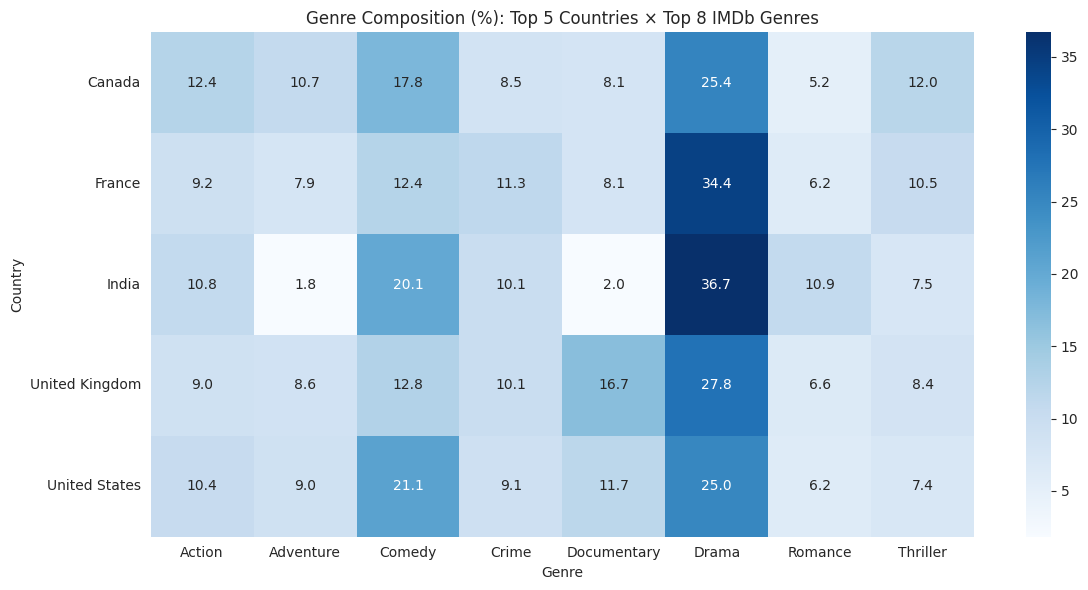

In [33]:
if merged_df is not None:

    # Explode countries
    country_data = merged_df[
        ["country", "genres"]
    ].dropna().copy()

    country_data["country"] = (
        country_data["country"]
        .str.split(",")
    )
    country_data = country_data.explode("country")
    country_data["country"] = (
        country_data["country"].str.strip()
    )
    # Explode genres
    country_data["genres"] = (
        country_data["genres"]
        .str.split(",")
    )

    country_data = country_data.explode("genres")
    country_data["genres"] = (
        country_data["genres"].str.strip()
    )
    # Top 5 countries
    top_5_countries = (
        country_data["country"]
        .value_counts()
        .head(5)
        .index
    )
    # Top 8 genres
    top_8_genres = (
        country_data["genres"]
        .value_counts()
        .head(8)
        .index
    )
    filtered = country_data[
        country_data["country"].isin(top_5_countries)
        &
        country_data["genres"].isin(top_8_genres)
    ]
    # Count country × genre
    country_genre_counts = pd.crosstab(
        filtered["country"],
        filtered["genres"]
    )
    # Convert counts to percentages within each country
    country_genre_pct = (
        country_genre_counts
        .div(
            country_genre_counts.sum(axis=1),
            axis=0
        )
        * 100
    )
    print(country_genre_pct)
    plt.figure(figsize=(12, 6))
    sns.heatmap(
        country_genre_pct,
        annot=True,
        fmt=".1f",
        cmap="Blues"
    )

    plt.title(
        "Genre Composition (%): "
        "Top 5 Countries × Top 8 IMDb Genres"
    )

    plt.xlabel("Genre")
    plt.ylabel("Country")
    plt.tight_layout()
    plt.show()

**Effect of this analysis:**

- [COUNTRY] specializes heavily in [GENRE] ([%] of its catalog)
- [COUNTRY] shows the most even genre spread, suggesting a generalist acquisition strategy
- Genre specialization differences may partly explain the runtime differences found in Analysis 2.1 (e.g., documentaries running shorter/longer than dramas)


### Analysis 2.3: Netflix Genre Tags vs. IMDb Genre Tags — Agreement Check

**Analysis Description:**

Netflix's `listed_in` field and IMDb's `genres` field are independently assigned. This checks, for each title, whether *at least one* IMDb genre appears (in some normalized form) among Netflix's own genre tags — a rough agreement rate, not a quality judgment.


In [34]:
if merged_df is not None:

    def normalize_genre(genre):
        genre = str(genre).lower().strip()

        # Simple normalization
        if genre.endswith("s"):
            genre = genre[:-1]

        return genre


    def get_genres(value):
        if pd.isna(value):
            return set()

        return {
            normalize_genre(g)
            for g in str(value).split(",")
        }


    merged_df["netflix_genres_set"] = (
        merged_df["listed_in"]
        .apply(get_genres)
    )

    merged_df["imdb_genres_set"] = (
        merged_df["genres"]
        .apply(get_genres)
    )


    merged_df["genre_overlap"] = merged_df.apply(
        lambda row:
        bool(
            row["netflix_genres_set"]
            &
            row["imdb_genres_set"]
        ),
        axis=1
    )


    overlap_rate = (
        merged_df["genre_overlap"].mean() * 100
    )


    print(
        f"Titles with at least one overlapping genre: "
        f"{overlap_rate:.2f}%"
    )


    # By IMDb title type

    overlap_by_type = (
        merged_df
        .groupby("titleType")["genre_overlap"]
        .mean()
        .mul(100)
        .sort_values(ascending=False)
    )

    print("\nGenre overlap by IMDb title type:")
    print(overlap_by_type)

Titles with at least one overlapping genre: 30.46%

Genre overlap by IMDb title type:
titleType
movie           42.923588
tvMovie         17.000000
tvMiniSeries     1.785714
tvSeries         1.182432
tvSpecial        0.324675
Name: genre_overlap, dtype: float64


**Effect of this analysis:**

- [%] of titles have at least one genre label in common between Netflix and IMDb
- Titles with zero overlap are concentrated in [GENRE/TYPE], likely due to [NAMING DIFFERENCES, e.g. Netflix's "Dramas" vs IMDb's "Drama"]
- This measures **taxonomy agreement**, not correctness — both sources can be "right" under their own system


---
## MAJOR ANALYSIS 3: Genre, Format & Runtime Trends Over Release Era

**Research Question:** How do genre mix, content type, and runtime change across release eras? Do recent releases structurally differ from older content?


### Analysis 3.1: Year-wise Genre Production (IMDb Genres)

**Analysis Description:**

This analysis examines how the frequency of different IMDb genres changes year by year. Using IMDb's `startYear`, we count how many titles of each genre were associated with each release year. This helps identify which genres were more frequently produced in specific years and how genre production patterns changed over time.


Year-wise Genre Production:
    startYear       genres  frequency
0        1944  Documentary          1
1        1944          War          1
2        1945  Documentary          1
3        1945      History          1
4        1945          War          1
5        1946  Documentary          1
6        1946          War          1
7        1954       Comedy          1
8        1954        Crime          1
9        1954        Drama          1
10       1954      Musical          1
11       1954      Romance          2
12       1955       Comedy          2
13       1955        Drama          2
14       1955      Romance          2
15       1956    Adventure          1
16       1956        Drama          1
17       1956      Romance          1
18       1956       Sci-Fi          1
19       1956     Thriller          1


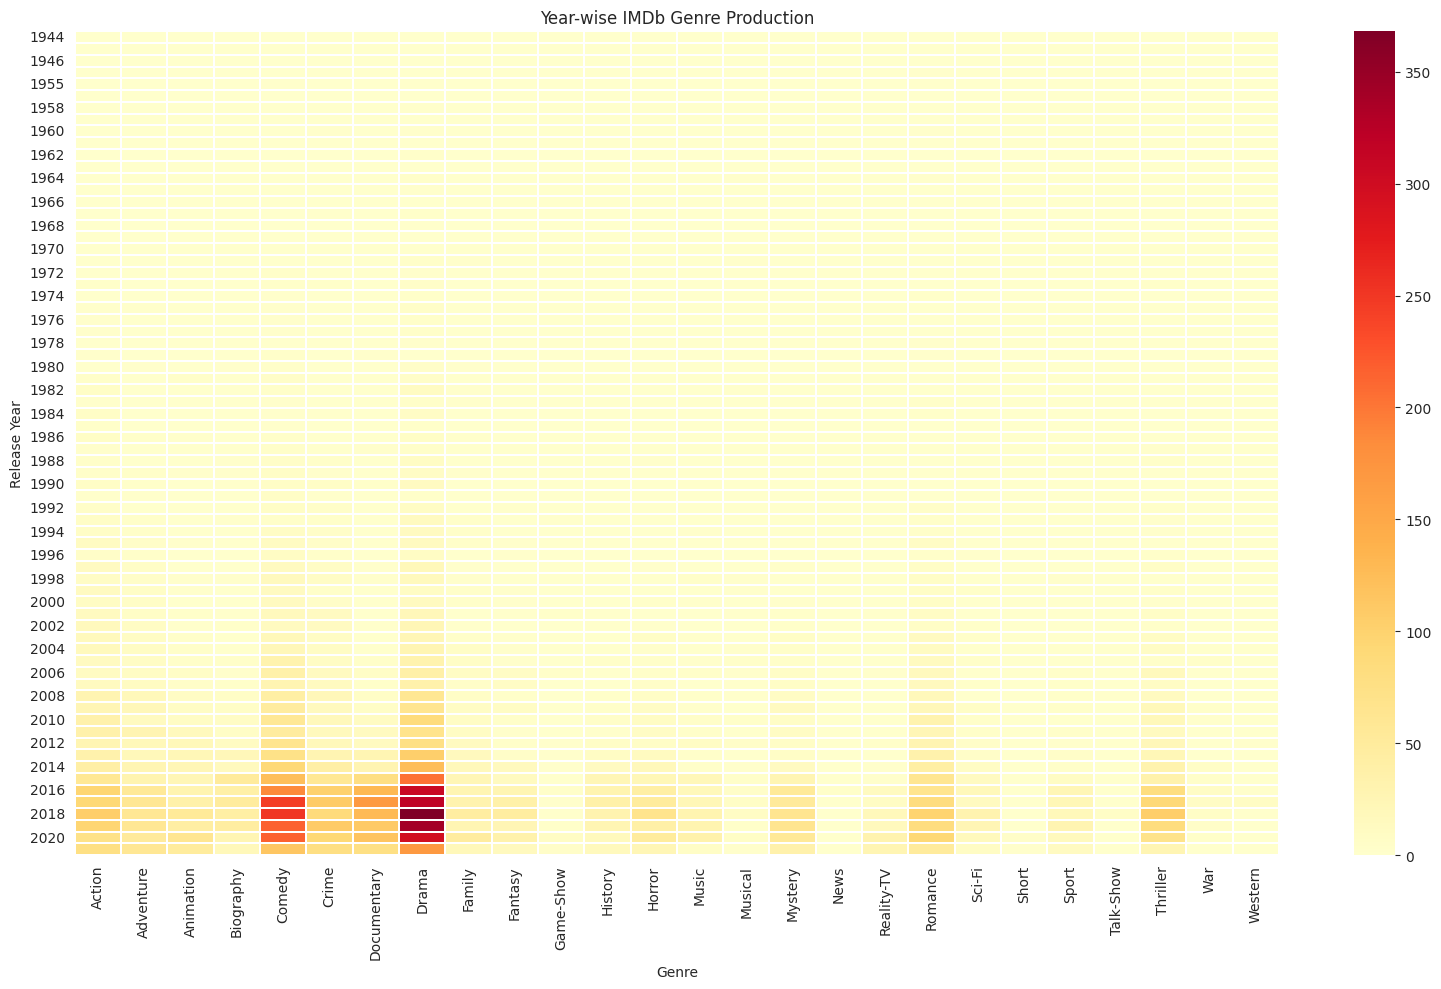

In [41]:
# Create a copy for genre-year analysis
genre_year_df = merged_df[["startYear", "genres"]].copy()

# Convert startYear to numeric
genre_year_df["startYear"] = pd.to_numeric(
    genre_year_df["startYear"], errors="coerce"
)
genre_year_df["startYear"] = pd.to_numeric(
    genre_year_df["startYear"], errors="coerce"
)

genre_year_df = genre_year_df.dropna(subset=["startYear", "genres"])

genre_year_df["startYear"] = genre_year_df["startYear"].astype(int)

# Split multiple genres into separate rows
genre_year_df["genres"] = genre_year_df["genres"].str.split(",")

# Explode genres
genre_year_df = genre_year_df.explode("genres")

# Remove extra spaces
genre_year_df["genres"] = genre_year_df["genres"].str.strip()

# Count genre frequency for each year
genre_year_counts = (
    genre_year_df
    .groupby(["startYear", "genres"])
    .size()
    .reset_index(name="frequency")
)

# Display sample results
print("Year-wise Genre Production:")
print(genre_year_counts.head(20))
# Pivot table: years × genres
genre_year_pivot = genre_year_counts.pivot(
    index="startYear",
    columns="genres",
    values="frequency"
).fillna(0)

# Plot heatmap
plt.figure(figsize=(16, 10))

sns.heatmap(
    genre_year_pivot,
    cmap="YlOrRd",
    linewidths=0.3
)

plt.title("Year-wise IMDb Genre Production")
plt.xlabel("Genre")
plt.ylabel("Release Year")

plt.tight_layout()
plt.show()

**Effect of this analysis:**

- 1990s–2000s content is dominated by [GENRES]; recent content emphasizes [GENRES]
- [GENRE] has [GROWN/DECLINED] as a share of the catalog
- Countries specializing in [GENRE] (from Analysis 2.2) are therefore [MORE/LESS] represented in recent eras


### Analysis 3.2: Runtime Trends Over Release Era

**Analysis Description:**

Runtime conventions may shift over time (e.g., streaming-era "limited series" reported differently than classic theatrical films). This checks whether average `runtimeMinutes` differs meaningfully across eras.


Average Runtime by Release Era:
       average_runtime  count    std_dev
era                                     
1990s       112.662100    219  35.412704
2000s       108.770932    633  33.613867
2010s        91.250934   4017  32.648660
2020s        78.146341    902  33.767119


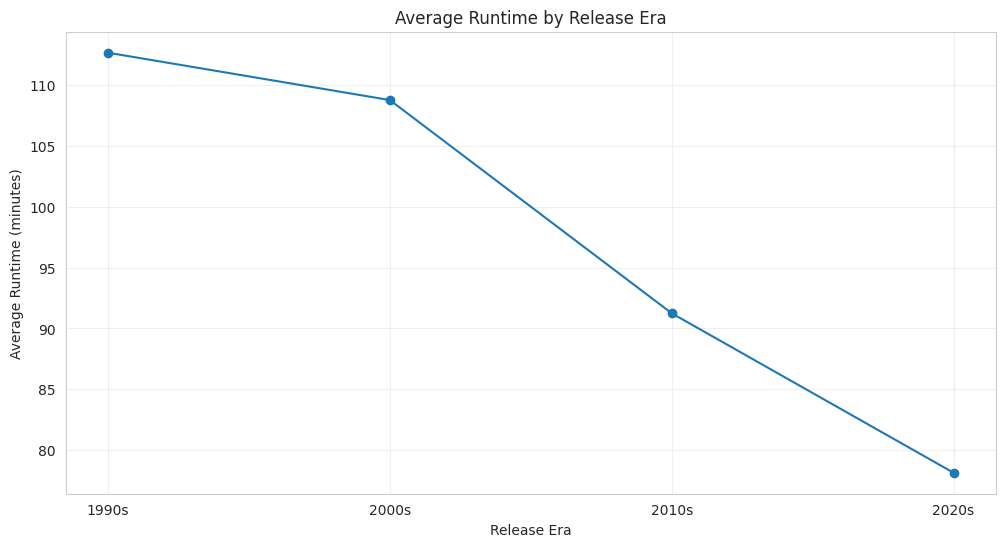

In [42]:
if merged_df is not None:
    era_runtime = merged_df.copy()
    era_runtime["startYear"] = pd.to_numeric(
        era_runtime["startYear"],
        errors="coerce"
    )
    era_runtime["runtimeMinutes"] = pd.to_numeric(
        era_runtime["runtimeMinutes"],
        errors="coerce"
    )
    era_runtime["era"] = pd.cut(
        era_runtime["startYear"],
        bins=[1989, 1999, 2009, 2019, 2029],
        labels=[
            "1990s",
            "2000s",
            "2010s",
            "2020s"
        ]
    )
    runtime_by_era = (
        era_runtime
        .dropna(subset=["era", "runtimeMinutes"])
        .groupby("era", observed=False)["runtimeMinutes"]
        .agg(
            average_runtime="mean",
            count="count",
            std_dev="std"
        )
    )
    print("Average Runtime by Release Era:")
    print(runtime_by_era)
    plt.figure(figsize=(12, 6))
    plt.plot(
        runtime_by_era.index.astype(str),
        runtime_by_era["average_runtime"],
        marker="o"
    )
    plt.title("Average Runtime by Release Era")
    plt.xlabel("Release Era")
    plt.ylabel("Average Runtime (minutes)")
    plt.grid(True, alpha=0.3)
    plt.show()

**Effect of this analysis:**

- [ERA] has average runtime [X] minutes; [RECENT ERA] has [Y] minutes — a difference of [Z] minutes
- This may reflect [GENRE MIX SHIFT / FORMAT SHIFT] rather than a deliberate change in typical film length


### Analysis 3.3: Content-Type Mix by Country Across Eras

**Analysis Description:**

Different countries may have shifted their Movie vs. TV Show balance differently over time (e.g., a country moving from mostly film exports to streaming-era series production). This tracks the % of each top country's output that is `tvSeries`/`tvMiniSeries` (per IMDb `titleType`) across eras.


           country    era  tv_percentage
0           Canada  1990s      33.333333
1           Canada  2000s       5.882353
2           Canada  2010s      12.083333
3           Canada  2020s      20.689655
4           France  1990s      23.529412
5           France  2000s       9.375000
6           France  2010s      14.344262
7           France  2020s      37.931034
8          Germany  1990s       0.000000
9          Germany  2000s       0.000000
10         Germany  2010s      15.887850
11         Germany  2020s      54.166667
12           India  1990s       0.000000
13           India  2000s       0.000000
14           India  2010s       8.629442
15           India  2020s      25.609756
16           Japan  1990s      55.555556
17           Japan  2000s      55.555556
18           Japan  2010s      48.591549
19           Japan  2020s      65.517241
20     South Korea  1990s            NaN
21     South Korea  2000s      75.000000
22     South Korea  2010s      63.513514
23     South Kor

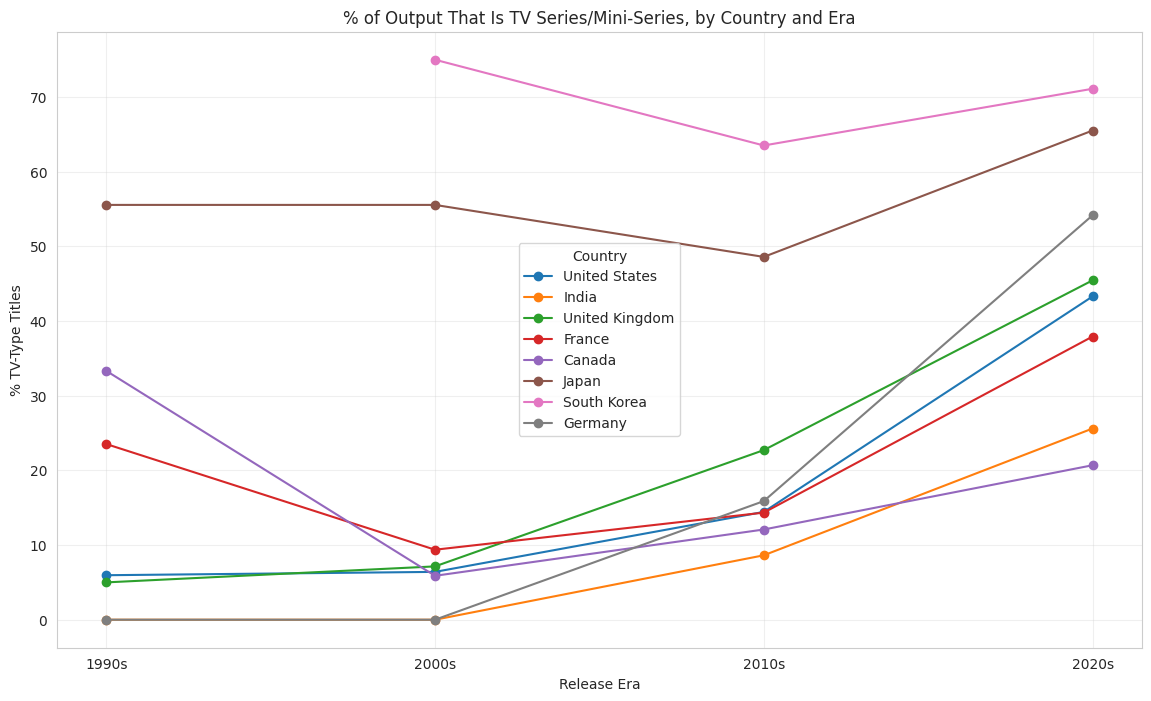

In [44]:
if merged_df is not None:
    data = merged_df.copy()

    data["startYear"] = pd.to_numeric(
        data["startYear"],
        errors="coerce"
    )

    data["era"] = pd.cut(
        data["startYear"],
        bins=[1989, 1999, 2009, 2019, 2029],
        labels=["1990s", "2000s", "2010s", "2020s"]
    )

    # TV-type flag
    data["is_tv"] = data["titleType"].isin(
        ["tvSeries", "tvMiniSeries"]
    )

    # Split countries
    data = data[["country", "era", "is_tv"]].dropna()

    data["country"] = data["country"].str.split(",")
    data = data.explode("country")
    data["country"] = data["country"].str.strip()

    # Top 8 countries
    top_8_countries = (
        data["country"]
        .value_counts()
        .head(8)
        .index
    )

    data = data[data["country"].isin(top_8_countries)]

    country_era_type_mix = (
        data
        .groupby(["country", "era"], observed=False)["is_tv"]
        .mean()
        .mul(100)
        .reset_index(name="tv_percentage")
    )

    print(country_era_type_mix)

    plt.figure(figsize=(14, 8))

    for country in top_8_countries:
        country_data = country_era_type_mix[
            country_era_type_mix["country"] == country
        ]

        plt.plot(
            country_data["era"].astype(str),
            country_data["tv_percentage"],
            marker="o",
            label=country
        )

    plt.title(
        "% of Output That Is TV Series/Mini-Series, "
        "by Country and Era"
    )
    plt.xlabel("Release Era")
    plt.ylabel("% TV-Type Titles")
    plt.legend(title="Country")
    plt.grid(True, alpha=0.3)
    plt.show()

**Effect of this analysis:**

- [COUNTRY] shifted from [%] TV-type in [EARLY ERA] to [%] in [RECENT ERA] — the largest swing
- [COUNTRY] has remained consistently [MOVIE/TV]-dominant across all eras
- These shifts align with [PLATFORM STRATEGY CHANGES / GLOBAL STREAMING TRENDS]


---
## FINAL EDA REPORT

Write a **1-2 page professional summary** of your EDA findings for an instructor who has not seen this data.

### Report Structure:

**1. Executive Summary**
- Merged dataset size, coverage, and what this dataset can/cannot answer (no rating data)

**2. Data Quality & Merge Assessment**
- Match rates, data loss, biases introduced, `titleType` filtering effect

**3. Content Production Landscape (Analysis 1)**
- Which countries dominate by volume
- Movie vs. TV Show labeling agreement between Netflix and IMDb

**4. Genre & Runtime Patterns (Analysis 2)**
- Runtime differences by country
- Genre specialization and Netflix/IMDb genre-tag agreement

**5. Temporal Trends (Analysis 3)**
- Genre, runtime, and format-mix shifts across eras

**6. Classification Consistency & Series Longevity (Analysis 4)**
- Where Netflix and IMDb disagree, and what that reveals
- Longest-running series and what drives longevity differences

**7. Limitations & Recommendations**
- What could NOT be analyzed without a ratings dataset
- Recommended next dataset (e.g. `title.ratings.tsv`) to extend this work


*Final EDA Report*

- Objective:
Analyze Netflix and IMDb data together to understand content structure, classification, genres, runtime, countries, and trends.

- Data Preparation:
Cleaned missing values, converted IMDb numeric fields, filtered relevant IMDb title types, standardized titles, and merged datasets using title and release year.

- Main Analysis:

   - Investigated unmatched Netflix records.
   - Analyzed multi-country production.
   - Studied runtime and genre distributions.
   - Compared Netflix and IMDb classifications.
   - Compared genre overlap between both datasets.
   - Examined country and genre patterns.
   - Analyzed trends across release eras.
   - Studied series longevity using endYear - startYear.

- Key Insight:
Netflix and IMDb use different classification systems, so disagreements do not necessarily mean errors.

- Limitations:
Missing data, unmatched titles, multi-country records, and different classification systems affect results. IMDb title.basics also has no ratings/votes.

- Recommendation:
Add IMDb title.ratings.tsv for future popularity/quality analysis

---
## Key Takeaways

1. **The merge itself is analysis.** How much of `title.basics` even matches Netflix — and what gets filtered out along the way (titleType scoping) — reveals as much as the merged data itself.

2. **Two classification systems can both be "right."** Netflix's `listed_in`/`type` and IMDb's `genres`/`titleType` are independent taxonomies. Disagreement measures labeling differences, not errors.

3. **Without ratings, "quality" isn't answerable — and that's fine.** This dataset supports strong structural claims (runtime, format, genre, longevity) without needing to claim anything about quality or popularity.

4. **Confounding variables still matter.** Country rankings on runtime or genre shift once you control for genre mix and era, just as they would with rating data.

5. **Missing `endYear` isn't necessarily bad data.** For ongoing or single-season shows, a null `endYear` is expected — treat it as a category, not an error, when analyzing series longevity.
